# Full-dataset pooling cohort: audit and ESM2 sidecars

Two completed preparation stages of the full-dataset pooling validation, analysed together:

- `full_pooling_audit/` — one read-only report per target from `full_pooling_validation.py audit`. Each report records the source-file signature, the raw model count, the accepted model names, and the exact rejection reason for every model that failed feature validation.
- `full_pooling_esm_sidecars/` — one ESM2 layer-33 sidecar HDF5 plus one audit JSON per target from `esm_sidecars.py prepare`, built against the accepted cohort.

This notebook describes **data coverage and provenance only**. It reads no loss histories, no predictions and no checkpoints, so it makes no statement about model accuracy. Eligibility is feature-based: DockQ labels are checked for finiteness and $[0,1]$ range, never used to select models. Source graphs are opened read-only, and no file in either directory is modified.

The questions are: how much of the raw model pool survives feature validation, why the rest is rejected, whether the surviving cohort still matches the frozen target split, and whether the ESM sidecars cover that cohort exactly.

In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

GATE=Path.cwd() if (Path.cwd()/'full_pooling_audit').is_dir() else Path.cwd()/'gate_run'
AUDIT=GATE/'full_pooling_audit'
SIDECAR=GATE/'full_pooling_esm_sidecars'
EXPORT=GATE/'full_pooling_cohort_analysis'; EXPORT.mkdir(exist_ok=True)
# Thresholds are documentation constants, not values derived from these results.
LAUNCHER_MINIMUM=150_000   # --minimum passed by cluster/submit_full_pooling_validation.sh
BUILDER_DEFAULT=180_000    # conservative default in full_pooling_validation.build
ESM_WIDTH=1280; ESM_LAYER=33
mpl.rcParams.update({'text.usetex':True,'font.family':'serif','font.serif':['Computer Modern Roman'],
    'mathtext.fontset':'cm','axes.labelsize':23,'xtick.labelsize':17,'ytick.labelsize':17,
    'legend.fontsize':17,'axes.spines.top':True,'axes.spines.right':True,'axes.linewidth':1.1})
COLORS={'eligible':'#0072B2','rejected':'#D55E00','empty':'#CC79A7','other':'#009E73'}
def save(fig,name):
    fig.savefig(EXPORT/(name+'.pdf'),bbox_inches='tight')
    fig.savefig(EXPORT/(name+'.png'),dpi=180,bbox_inches='tight')
    plt.show()
def tex(s):
    return s.replace('\\','').replace('_',r'\_').replace('%',r'\%').replace('&',r'\&').replace('#',r'\#')
def mono(s):
    return r'\texttt{'+tex(s)+'}'
reports={p.stem: json.loads(p.read_text()) for p in sorted(AUDIT.glob('*.json'))}
print(f'{len(reports)} audit reports in {AUDIT.name}; {len(list(SIDECAR.glob("*.hdf5")))} sidecar HDF5 files in {SIDECAR.name}.')

146 audit reports in full_pooling_audit; 146 sidecar HDF5 files in full_pooling_esm_sidecars.


## Audit integrity

Before any counting, check that the reports are internally consistent and mutually comparable. Every report must account for each raw model exactly once, as either accepted or rejected; the two sets must be disjoint; every rejected model must carry a reason and the per-reason tallies must sum to the rejection count.

Reports are only comparable if they were produced by the same audit code. `full_pooling_validation.audit_code_signature` hashes `full_pooling_validation.py` together with `add_interface_node_degree.py`, and the builder refuses any report whose stored signature no longer matches the current files and source-file stats. A single shared `audit_code` across all reports therefore establishes that one code version produced the whole cohort. It does not prove the code matches the copy in this working tree; the check that enforces that is in `build`, which cannot run here because the cluster source graphs are not mounted locally.

In [2]:
rows=[]
codes=set(); reasons_by_target={}
for target,r in reports.items():
    accepted=r['accepted']; rejected=r['rejected']
    assert r['target']==target
    assert len(accepted)+len(rejected)==r['raw_models'], target
    assert not set(accepted) & set(rejected), target
    assert len(set(accepted))==len(accepted), target
    assert sum(r['rejection_counts'].values())==len(rejected), target
    assert set(r['rejection_counts'])==set(rejected.values()), target
    signature=r['signature']; codes.add(signature['audit_code'])
    assert signature['rsasa'] is not None, target        # every target has an rSASA CSV
    assert signature['graph']['path'].endswith(f'{target}.hdf5')
    widths={tuple(w) for w in r['feature_widths']}
    assert len(widths)<=1, target                        # one input layout per target
    reasons_by_target[target]=r['rejection_counts']
    rows.append(dict(target=target, raw=r['raw_models'], eligible=len(accepted), rejected=len(rejected),
        node_width=(next(iter(widths))[0] if widths else np.nan),
        edge_width=(next(iter(widths))[1] if widths else np.nan),
        graph_bytes=signature['graph']['size'], graph_mtime_ns=signature['graph']['mtime_ns'],
        rsasa_bytes=signature['rsasa']['size']))
audit=pd.DataFrame(rows).set_index('target').sort_index()
audit['eligible_fraction']=audit.eligible/audit.raw
assert len(codes)==1, codes
widths={(int(a),int(b)) for a,b in audit[['node_width','edge_width']].dropna().to_numpy()}
assert len(widths)==1, widths                            # the builder aborts on mixed widths
NODE_WIDTH,EDGE_WIDTH=next(iter(widths))
print(f'One audit code across all {len(reports)} reports: {sorted(codes)[0][:16]}...')
print(f'Every target has an rSASA CSV recorded in its signature.')
print(f'Uniform input layout: node width {NODE_WIDTH}, edge width {EDGE_WIDTH}.')
print(f'Source graphs: {audit.graph_bytes.sum()/2**30:,.1f} GiB across {len(audit)} files '
      f'({audit.graph_bytes.min()/2**30:.2f}--{audit.graph_bytes.max()/2**30:.2f} GiB each).')

One audit code across all 146 reports: 8b5bd9f2c2280763...
Every target has an rSASA CSV recorded in its signature.
Uniform input layout: node width 24, edge width 4.
Source graphs: 121.0 GiB across 146 files (0.14--2.07 GiB each).


## Cohort size against the release gate

`build` refuses to write a training matrix unless the eligible pool reaches its minimum. The standalone builder keeps a conservative default of 180,000; the launcher passes 150,000 explicitly after the documented threshold-only build failure. The gate counts **eligible models**, not raw HDF5 groups, so the raw total is not the relevant number.

In [3]:
raw_total=int(audit.raw.sum()); eligible_total=int(audit.eligible.sum()); rejected_total=raw_total-eligible_total
gate=pd.DataFrame([
    dict(threshold='Launcher minimum', required=LAUNCHER_MINIMUM),
    dict(threshold='Builder default', required=BUILDER_DEFAULT)])
gate['eligible']=eligible_total
gate['margin']=gate.eligible-gate.required
gate['margin_pct']=100*gate.margin/gate.required
gate['passes']=gate.margin>=0
gate=gate.set_index('threshold')
gate.to_csv(EXPORT/'coverage_gate.csv')
display(gate)
print(f'Raw models {raw_total:,}; eligible {eligible_total:,} ({100*eligible_total/raw_total:.2f}%); '
      f'rejected {rejected_total:,} ({100*rejected_total/raw_total:.2f}%).')
print(f'Eligible targets {int((audit.eligible>0).sum())} of {len(audit)}; '
      f'{int((audit.eligible==0).sum())} targets contribute nothing.')

,required,eligible,margin,margin_pct,passes
threshold,,,,,
Launcher minimum,150000,150938,938,0.625333,True
Builder default,180000,150938,-29062,-16.145556,False


Raw models 189,710; eligible 150,938 (79.56%); rejected 38,772 (20.44%).
Eligible targets 125 of 146; 21 targets contribute nothing.


The eligible pool clears the launcher minimum by a small margin and falls well short of the conservative default. The gate is therefore doing real work here: this cohort exists only because the threshold was lowered deliberately, which is exactly the decision the validation document reserves for inspection of the coverage report. A margin this thin is worth stating plainly — losing roughly 0.6% of the eligible models, for instance by one more target developing a missing derived feature, would block the GPU release again.

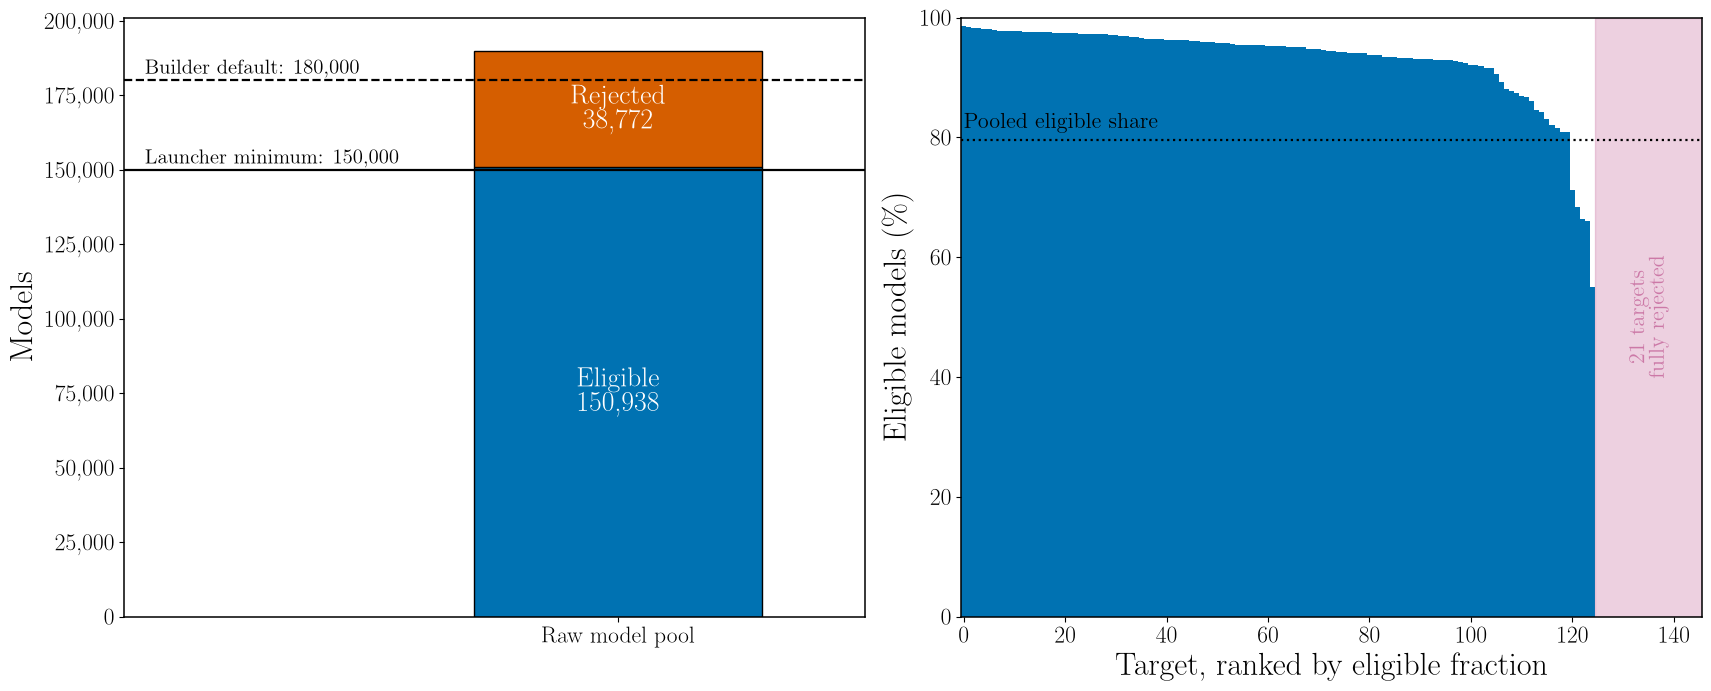

In [4]:
fig,axes=plt.subplots(1,2,figsize=(17,6.8),constrained_layout=True)
ax=axes[0]
ax.bar([0],[eligible_total],width=.7,color=COLORS['eligible'],edgecolor='black')
ax.bar([0],[rejected_total],width=.7,bottom=[eligible_total],color=COLORS['rejected'],edgecolor='black')
for y,text,style in [(LAUNCHER_MINIMUM,'Launcher minimum','-'),(BUILDER_DEFAULT,'Builder default','--')]:
    ax.axhline(y,color='black',ls=style,lw=1.6)
    ax.text(-1.15,y*1.005,f'{text}: {y:,}',ha='left',va='bottom',fontsize=15)
ax.text(0,eligible_total/2,f'Eligible\n{eligible_total:,}',ha='center',va='center',fontsize=20,color='white')
ax.text(0,eligible_total+rejected_total/2,f'Rejected\n{rejected_total:,}',ha='center',va='center',fontsize=20,color='white')
ax.set_xticks([0],['Raw model pool'])
ax.set_xlim(-1.2,.6); ax.set_ylim(0,raw_total*1.06); ax.set_ylabel('Models')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax=axes[1]
order=audit.sort_values('eligible_fraction',ascending=False)
ax.bar(np.arange(len(order)),100*order.eligible_fraction,color=COLORS['eligible'],width=1.0)
start=int((order.eligible>0).sum())
ax.axvspan(start-.5,len(order)-.5,color=COLORS['empty'],alpha=.35)
ax.text((start+len(order))/2-.5,50,f'{len(order)-start} targets\nfully rejected',ha='center',va='center',
        fontsize=16,color=COLORS['empty'],rotation=90)
ax.set_xlabel('Target, ranked by eligible fraction'); ax.set_ylabel(r'Eligible models (\%)')
ax.set_xlim(-.5,len(order)-.5); ax.set_ylim(0,100)
ax.axhline(100*eligible_total/raw_total,color='black',ls=':',lw=1.6)
ax.text(0,100*eligible_total/raw_total+2,'Pooled eligible share',ha='left',fontsize=16)
save(fig,'cohort_gate_and_coverage')

## Per-target coverage

The pooled share hides a bimodal picture: most targets lose a modest and similar fraction of their models, while a distinct group loses everything. Neither group is small enough to ignore, and the two have different causes, so they are separated here before the rejection reasons are examined.

In [5]:
nonempty=audit[audit.eligible>0]; empty=audit[audit.eligible==0]
summary=pd.DataFrame({
    'targets':[len(audit),len(nonempty),len(empty)],
    'raw_models':[int(audit.raw.sum()),int(nonempty.raw.sum()),int(empty.raw.sum())],
    'eligible_models':[int(audit.eligible.sum()),int(nonempty.eligible.sum()),0],
    'median_eligible_fraction':[audit.eligible_fraction.median(),nonempty.eligible_fraction.median(),0.0],
    'min_eligible_fraction':[audit.eligible_fraction.min(),nonempty.eligible_fraction.min(),0.0],
    'max_eligible_fraction':[audit.eligible_fraction.max(),nonempty.eligible_fraction.max(),0.0]},
    index=['All targets','Targets with eligible models','Fully rejected targets'])
display(summary.round(4))
audit.to_csv(EXPORT/'per_target_audit.csv')
print('Fully rejected targets ({}): {}'.format(len(empty),', '.join(empty.index)))
print(f'Among targets that contribute, the eligible fraction spans '
      f'{100*nonempty.eligible_fraction.min():.1f}--{100*nonempty.eligible_fraction.max():.1f}% '
      f'(median {100*nonempty.eligible_fraction.median():.1f}%).')

,targets,raw_models,eligible_models,median_eligible_fraction,min_eligible_fraction,max_eligible_fraction
All targets,146,189710,150938,0.9433,0.0000,0.9864
Targets with eligible models,125,161856,150938,0.9529,0.5495,0.9864
Fully rejected targets,21,27854,0,0.0000,0.0000,0.0000


Fully rejected targets (21): 1atn, 1bkd, 1c3a, 1ggp, 1itb, 1kfu, 1pdk, 1spp, 1tfo, 2d5r, 2dvw, 2hla, 2hsm, 2hth, 2oul, 2pe6, 2wmp, 3gfk, 3k9p, 3ona, 3qc8
Among targets that contribute, the eligible fraction spans 55.0--98.6% (median 95.3%).


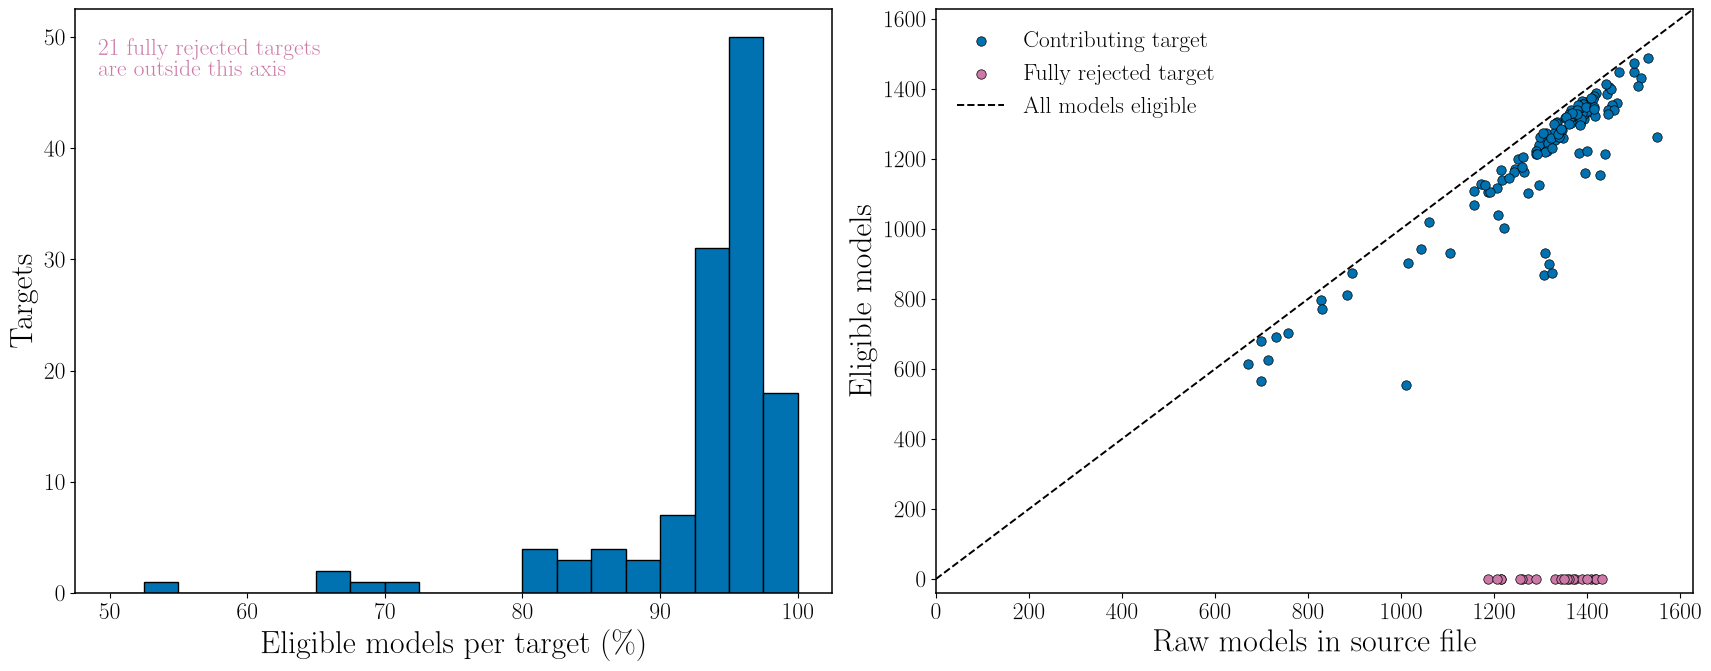

In [6]:
fig,axes=plt.subplots(1,2,figsize=(17,6.6),constrained_layout=True)
ax=axes[0]
ax.hist(100*nonempty.eligible_fraction,bins=np.arange(50,102,2.5),color=COLORS['eligible'],edgecolor='black')
ax.set_xlabel(r'Eligible models per target (\%)'); ax.set_ylabel('Targets')
ax.text(.03,.95,f'{len(empty)} fully rejected targets\nare outside this axis',transform=ax.transAxes,
        va='top',fontsize=17,color=COLORS['empty'])
ax=axes[1]
ax.scatter(nonempty.raw,nonempty.eligible,s=46,color=COLORS['eligible'],edgecolor='black',lw=.5,label='Contributing target')
ax.scatter(empty.raw,empty.eligible,s=46,color=COLORS['empty'],edgecolor='black',lw=.5,label='Fully rejected target')
lim=[0,audit.raw.max()*1.05]
ax.plot(lim,lim,color='black',ls='--',lw=1.4,label='All models eligible')
ax.set_xlim(*lim); ax.set_ylim(-40,lim[1])
ax.set_xlabel('Raw models in source file'); ax.set_ylabel('Eligible models')
ax.legend(frameon=False,loc='upper left')
save(fig,'per_target_coverage')

No target keeps all of its models, and the shortfall is not proportional to file size: the contributing targets sit close to, but consistently below, the diagonal. The fully rejected targets are not unusually small, so the losses are not a sampling artefact of thin source files.

## Why models are rejected

`validate_graph` raises a distinct message for each failure mode it checks — missing datasets, non-finite or mis-shaped features, empty interface masks, invalid DockQ labels, negative distances or areas, and interface degrees that disagree with the recomputed contacts. Only the messages actually observed appear below. The two HDF5 `KeyError` messages are shortened to the missing object name; all other messages are kept verbatim.

In [7]:
def short_reason(message):
    hit=re.search(r"object '([^']+)' doesn't exist",message)
    return f'Missing {hit.group(1)}' if hit else message.strip('"')
tallies={}
for target,counts in reasons_by_target.items():
    for message,n in counts.items(): tallies[short_reason(message)]=tallies.get(short_reason(message),0)+n
reason_table=pd.Series(tallies).sort_values(ascending=False).rename('models').to_frame()
reason_table['share_of_rejections_pct']=100*reason_table.models/rejected_total
reason_table['share_of_raw_pct']=100*reason_table.models/raw_total
reason_table['targets_affected']=[sum(1 for c in reasons_by_target.values()
    if any(short_reason(m)==reason for m in c)) for reason in reason_table.index]
reason_table.to_csv(EXPORT/'rejection_reasons.csv')
display(reason_table.round(3))
assert int(reason_table.models.sum())==rejected_total
print(f'{len(reason_table)} distinct rejection messages across {rejected_total:,} rejected models.')

,models,share_of_rejections_pct,share_of_raw_pct,targets_affected
Missing interface_node_degree,37528,96.791,19.782,146
Missing node_features,1243,3.206,0.655,144
Missing/nonfinite rSASA,1,0.003,0.001,1


3 distinct rejection messages across 38,772 rejected models.


Almost every rejection is a **missing dataset**, not a failed numerical test. `interface_node_degree` is a derived feature added to the graphs after the fact by `add_interface_node_degree.py`; where it was never written, the audit cannot verify it against the contacts and rejects the model. A smaller group is missing the whole `node_features` group. Exactly one model fails a value check rather than a presence check.

This matters for interpretation: the cohort is limited by **incomplete feature propagation in the source graphs**, not by structural defects in the models themselves. The validation document is explicit that the pipeline does not invent the missing features, and nothing here suggests the rejected models are of poor quality — only that they cannot be verified.

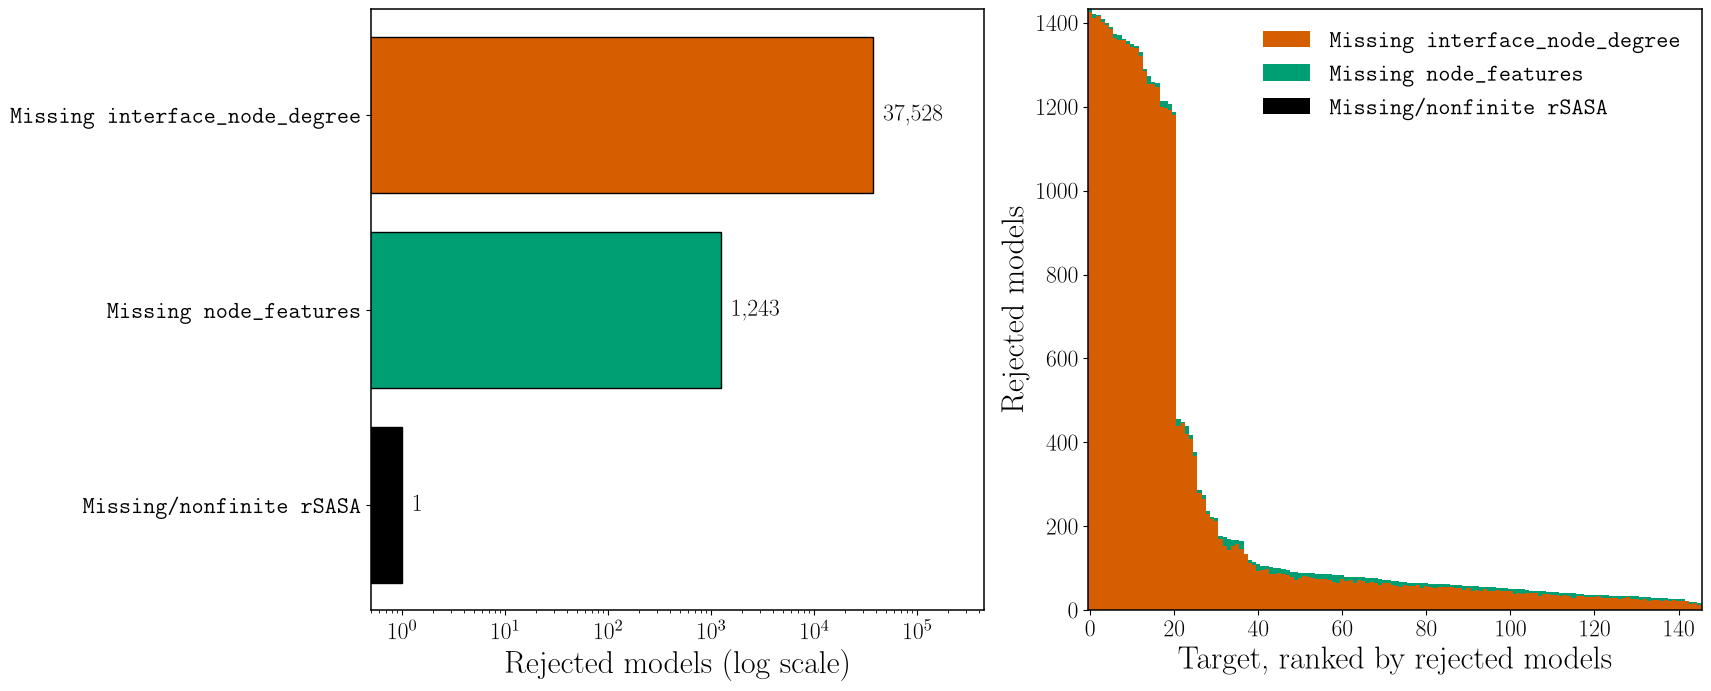

In [8]:
per_target_reason=pd.DataFrame(0,index=audit.index,columns=reason_table.index,dtype=int)
for target,counts in reasons_by_target.items():
    for message,n in counts.items(): per_target_reason.loc[target,short_reason(message)]+=n
per_target_reason.to_csv(EXPORT/'rejections_by_target.csv')
fig,axes=plt.subplots(1,2,figsize=(17,6.8),constrained_layout=True)
ax=axes[0]
palette=[COLORS['rejected'],COLORS['other'],'black'][:len(reason_table)]
bars=ax.barh(np.arange(len(reason_table)),reason_table.models,color=palette,edgecolor='black')
ax.set_yticks(np.arange(len(reason_table)),[mono(r) for r in reason_table.index])
ax.invert_yaxis(); ax.set_xscale('log'); ax.set_xlim(.5,reason_table.models.max()*12)
ax.set_xlabel('Rejected models (log scale)')
for bar,n in zip(bars,reason_table.models):
    ax.text(n*1.25,bar.get_y()+bar.get_height()/2,f'{n:,}',va='center',fontsize=17)
ax=axes[1]
order=per_target_reason.loc[audit.sort_values('rejected',ascending=False).index]
bottom=np.zeros(len(order))
for reason,color in zip(reason_table.index,palette):
    ax.bar(np.arange(len(order)),order[reason],bottom=bottom,color=color,width=1.0,label=mono(reason))
    bottom=bottom+order[reason].to_numpy()
ax.set_xlabel('Target, ranked by rejected models'); ax.set_ylabel('Rejected models')
ax.set_xlim(-.5,len(order)-.5)
ax.legend(frameon=False,loc='upper right')
save(fig,'rejection_reasons')

## The rejections are concentrated in synthetic decoy families

Model names in the source files fall into three naming families. Splitting the audit by family shows that the loss is not spread evenly over the pool.

In [9]:
def family(name):
    for prefix in ('complex.','random_','sampled_'):
        if name.startswith(prefix): return prefix.rstrip('._')
    return 'other'
family_rows=[]; family_targets={}
for target,r in reports.items():
    for name in r['accepted']:
        family_rows.append((family(name),target,True)); family_targets.setdefault(family(name),set()).add(target)
    for name in r['rejected']:
        family_rows.append((family(name),target,False)); family_targets.setdefault(family(name),set()).add(target)
families=pd.DataFrame(family_rows,columns=['family','target','accepted'])
family_table=families.groupby('family').agg(models=('accepted','size'),eligible=('accepted','sum'))
family_table['rejected']=family_table.models-family_table.eligible
family_table['eligible_pct']=100*family_table.eligible/family_table.models
family_table['targets_present']=[len(family_targets[f]) for f in family_table.index]
family_table=family_table.sort_values('models',ascending=False)
family_table.to_csv(EXPORT/'model_families.csv')
display(family_table.round(2))
synthetic=sorted(set().union(*[family_targets[f] for f in family_table.index if f!='complex']))
fully_rejected=sorted(audit[audit.eligible==0].index)
print(f'Every eligible model belongs to the "complex" family: '
      f'{family_table.loc["complex","eligible"]:,} of {eligible_total:,}.')
print(f'{len(synthetic)} targets carry synthetic decoy families; '
      f'{len(set(synthetic)&set(fully_rejected))} of those are fully rejected.')
print('Fully rejected targets without synthetic families: '
      f'{sorted(set(fully_rejected)-set(synthetic))}')

,models,eligible,rejected,eligible_pct,targets_present
family,,,,,
complex,164502,150938,13564,91.75,127
sampled,17545,0,17545,0.00,19
random,7663,0,7663,0.00,19


Every eligible model belongs to the "complex" family: 150,938 of 150,938.
19 targets carry synthetic decoy families; 19 of those are fully rejected.
Fully rejected targets without synthetic families: ['1atn', '1bkd']


The synthetic `random_*` and `sampled_*` families are rejected in their entirety, and they occur only in targets that end up contributing nothing. In other words the fully rejected targets are not a random subset: they are the ones whose source files were rebuilt with a different decoy-generation route that never received the derived interface features. Two fully rejected targets carry no synthetic families and lose their `complex` models for the same missing-feature reason.

This is an association within a completed audit, not a demonstrated cause. It does say where a repair effort would pay off: regenerating `interface_node_degree` for these files is a targeted job on a known list of targets, not a whole-dataset rebuild.

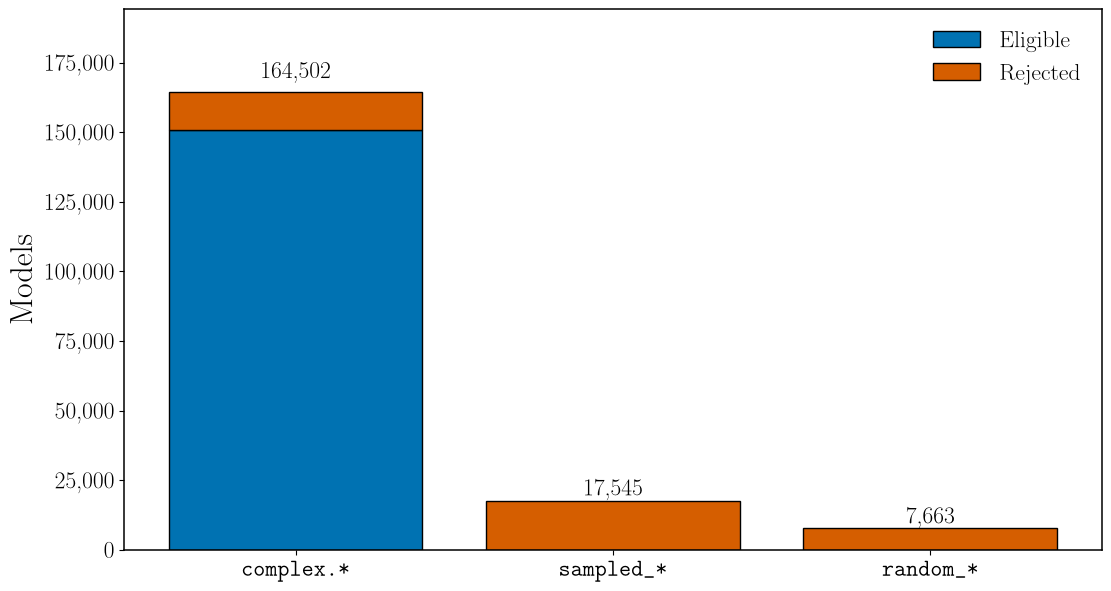

In [10]:
fig,ax=plt.subplots(figsize=(11,5.8),constrained_layout=True)
x=np.arange(len(family_table))
ax.bar(x,family_table.eligible,color=COLORS['eligible'],edgecolor='black',label='Eligible')
ax.bar(x,family_table.rejected,bottom=family_table.eligible,color=COLORS['rejected'],edgecolor='black',label='Rejected')
for i,(_,row) in enumerate(family_table.iterrows()):
    ax.text(i,row.models*1.02,f'{int(row.models):,}',ha='center',va='bottom',fontsize=17)
ax.set_xticks(x,[mono(f+'_*') if f!='complex' else mono('complex.*') for f in family_table.index])
ax.set_ylabel('Models'); ax.set_ylim(0,family_table.models.max()*1.18)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax.legend(frameon=False,loc='upper right')
save(fig,'model_families')

## Does the surviving cohort still match the frozen split?

`build` blocks training on two membership conditions. A target with eligible models that is absent from the frozen split (`eligible_targets_outside_frozen_split`) and a frozen-split target left with no eligible models (`frozen_targets_without_eligible_models`) both abort the build; neither is silently reassigned or dropped. Reproducing that check here uses the split manifests that were downloaded with the earlier experiments.

In [11]:
candidates=sorted(GATE.glob('*/target_splits.json'))+sorted(GATE.glob('*/*/target_splits.json'))
assert candidates, 'No target_splits.json manifest available locally'
manifests={}
for path in candidates:
    splits=json.loads(path.read_text())['splits']
    key=tuple(tuple(sorted(splits[s]['targets'])) for s in ('train','val','test'))
    manifests.setdefault(key,[]).append(path)
assert len(manifests)==1, 'Local manifests disagree on target membership'
membership,sources=next(iter(manifests.items()))
assignment={t:s for s,targets in zip(('train','val','test'),membership) for t in targets}
frozen=set(assignment)
eligible_targets={t for t,r in reports.items() if r['accepted']}
outside=sorted(eligible_targets-frozen); absent=sorted(frozen-eligible_targets)
assert not outside, outside
assert not absent, absent
split_table=pd.DataFrame([
    dict(split=s,
         targets=sum(assignment[t]==s for t in frozen),
         eligible_models=int(sum(audit.loc[t,'eligible'] for t in frozen if assignment[t]==s)))
    for s in ('train','val','test')]).set_index('split')
split_table['share_pct']=100*split_table.eligible_models/split_table.eligible_models.sum()
split_table.to_csv(EXPORT/'split_cohort.csv')
display(split_table.round(2))
print(f'Frozen split read from {len(sources)} agreeing manifest(s), e.g. {sources[0].relative_to(GATE)}')
print(f'Eligible targets outside the frozen split: {len(outside)}. '
      f'Frozen targets without eligible models: {len(absent)}. Both gates pass.')
print(f'The {len(audit)-len(frozen)} fully rejected targets were already excluded from the frozen split, '
      'so they are reported exclusions rather than new losses.')

,targets,eligible_models,share_pct
split,,,
train,90,109147,72.31
val,10,11325,7.50
test,25,30466,20.18


Frozen split read from 7 agreeing manifest(s), e.g. voronoi_10pct_50epochs/target_splits.json
Eligible targets outside the frozen split: 0. Frozen targets without eligible models: 0. Both gates pass.
The 21 fully rejected targets were already excluded from the frozen split, so they are reported exclusions rather than new losses.


The membership gates pass exactly: the 125 targets with eligible models are precisely the 125 targets in the frozen split, and the 21 fully rejected targets were already excluded when the split was frozen. The full-data audit therefore reproduces the earlier cohort's target membership rather than redefining it — which is the only condition under which the frozen split may be reused without reassignment.

In [12]:
scaling=[]
for path in sources:
    splits=json.loads(path.read_text())['splits']
    counts={s:splits[s]['sample_count'] for s in ('train','val','test')}
    scaling.append(dict(manifest=str(path.relative_to(GATE)),**counts,total=sum(counts.values())))
scaling=pd.DataFrame(scaling)
scaling['ratio_to_audit']=split_table.eligible_models.sum()/scaling.total
scaling=scaling.sort_values('total').reset_index(drop=True)
display(scaling.round(3))
exact=scaling[np.isclose(scaling.ratio_to_audit,1.0)]
subset=scaling[~np.isclose(scaling.ratio_to_audit,1.0)]
if len(exact):
    print(f'{len(exact)} manifest(s) record exactly the audited eligible counts per split '
          f'({split_table.eligible_models.to_dict()}), an independent reproduction of this cohort.')
if len(subset):
    print(f'{len(subset)} manifest(s) are the 10% subset, smaller by a factor of '
          f'{subset.ratio_to_audit.min():.2f}--{subset.ratio_to_audit.max():.2f}.')

,manifest,train,val,test,total,ratio_to_audit
0,voronoi_10pct_50epochs/target_splits.json,10910,1132,3044,15086,10.005
1,full_feature_ablation_lr5e-6/gat2_01_rsasa_i/t...,109147,11325,30466,150938,1.000
2,full_feature_ablation_lr5e-6/gat2_02_plus_inte...,109147,11325,30466,150938,1.000
3,full_feature_ablation_lr5e-6/gat2_03_plus_voro...,109147,11325,30466,150938,1.000
4,full_feature_ablation_lr5e-6/gat4_residual_01_...,109147,11325,30466,150938,1.000
5,full_feature_ablation_lr5e-6/gat4_residual_02_...,109147,11325,30466,150938,1.000
6,full_feature_ablation_lr5e-6/gat4_residual_03_...,109147,11325,30466,150938,1.000


6 manifest(s) record exactly the audited eligible counts per split ({'train': 109147, 'val': 11325, 'test': 30466}), an independent reproduction of this cohort.
1 manifest(s) are the 10% subset, smaller by a factor of 10.01--10.01.


Two independent lines agree with this audit. The `full_feature_ablation_lr5e-6` manifests, written by an earlier full-data experiment over the same source directory, record per-split sample counts identical to the eligible counts recomputed here. The `voronoi_10pct_50epochs` manifest is smaller by a factor of almost exactly ten in every split, consistent with its documented 10% subset. Identical counts are a strong consistency check but not a proof of identical model lists; the audit reports carry the exact accepted names if a name-level comparison is ever needed.

## ESM2 sidecar audits

`esm_sidecars.prepare` aligns each graph's `node_reference` sequence to the target FASTA and the per-chain embedding labels, rejecting ambiguous mappings unless the candidate embeddings are identical. The documented contract is strict: every selected graph must have a valid embedding, failures are reported per target rather than quietly shrinking the cohort, and the final HDF5 is only moved into place when there are no failures.

In [13]:
sidecar_audits={p.name.split('.')[0]: json.loads(p.read_text()) for p in sorted(SIDECAR.glob('*.audit.json'))}
rows=[]
for target,a in sidecar_audits.items():
    assert a['target']==target
    assert a['accepted']==a['expected']-len(a['failures']), target
    rows.append(dict(target=target, expected=a['expected'], accepted=a['accepted'],
        failures=len(a['failures']), unique_layouts=a['unique_layouts'],
        width=(a['widths'][0] if a['widths'] else np.nan), distinct_widths=len(a['widths'])))
sidecar=pd.DataFrame(rows).set_index('target').sort_index()
assert set(sidecar.index)==set(audit.index)
assert (sidecar.expected==audit.eligible).all()             # sidecars target the audited cohort exactly
assert (sidecar.failures==0).all()
assert (sidecar.accepted==sidecar.expected).all()
assert (sidecar.distinct_widths<=1).all()
observed_widths=set(sidecar.width.dropna().astype(int))
assert observed_widths=={ESM_WIDTH}, observed_widths
assert (sidecar.loc[sidecar.expected>0,'unique_layouts']==1).all()
assert (sidecar.loc[sidecar.expected==0,'unique_layouts']==0).all()
sidecar.to_csv(EXPORT/'per_target_sidecar.csv')
print(f'{len(sidecar)} sidecar audits; expected {int(sidecar.expected.sum()):,} graphs, '
      f'accepted {int(sidecar.accepted.sum()):,}, alignment failures {int(sidecar.failures.sum())}.')
print(f'Sidecar expectations equal the audited eligible counts for every target.')
print(f'Every embedding is {ESM_WIDTH} wide, and each contributing target resolves to exactly one node layout.')

146 sidecar audits; expected 150,938 graphs, accepted 150,938, alignment failures 0.
Sidecar expectations equal the audited eligible counts for every target.
Every embedding is 1280 wide, and each contributing target resolves to exactly one node layout.


## Verifying the sidecar files themselves

The audit JSONs are written by the same process that wrote the HDF5 files, so they are not an independent check. This section opens every sidecar read-only and verifies the structure directly: the model names present, that each model dataset is a hard link to the shared embedding rather than a copy, the dataset shape and dtype, the stored `reference_sha256` against the group key, and the provenance recorded for each unique layout.

In [14]:
rows=[]; provenance_rows=[]
for target in sidecar.index:
    accepted=sorted(reports[target]['accepted'])
    with h5py.File(SIDECAR/f'{target}.hdf5','r') as f:
        assert set(f)=={'models','embeddings'}, target
        assert f.attrs['layer']==ESM_LAYER, target
        assert f.attrs['source_graph'].endswith(f'{target}.hdf5'), target
        assert sorted(f['models'])==accepted, target          # exactly the audited cohort, no more
        offsets={}
        for digest,ds in f['embeddings'].items():
            assert ds.attrs['reference_sha256']==digest, target
            assert ds.dtype==np.float32 and ds.shape[1]==ESM_WIDTH, target
            offsets[ds.id.get_offset()]=digest
            values=ds[()]
            assert np.isfinite(values).all(), target
            info=json.loads(ds.attrs['provenance'])
            assert info['layer']==ESM_LAYER, target
            provenance_rows.append(dict(target=target, residues=ds.shape[0],
                mapping_method=info['mapping_method'], equivalent_assignments=info['equivalent_assignments'],
                chains=len(info['chains']), graph_chain_ids=','.join(info['chains']),
                embedding_chains=','.join(c['embedding_chain'] for c in info['chains'].values()),
                stored_bytes=ds.id.get_storage_size(), mean=float(values.mean()), sd=float(values.std()),
                row_norm=float(np.linalg.norm(values,axis=1).mean())))
        shared=sum(ds.id.get_offset() in offsets for ds in f['models'].values())
        rows.append(dict(target=target, models=len(f['models']), stored_embeddings=len(f['embeddings']),
            hard_linked=shared, file_bytes=(SIDECAR/f'{target}.hdf5').stat().st_size))
verified=pd.DataFrame(rows).set_index('target')
provenance=pd.DataFrame(provenance_rows).set_index('target')
assert (verified.models==sidecar.accepted).all()
assert (verified.stored_embeddings==sidecar.unique_layouts).all()
assert (verified.hard_linked==verified.models).all()          # every model is a link, none a copy
verified.to_csv(EXPORT/'sidecar_files_verified.csv')
provenance.to_csv(EXPORT/'sidecar_provenance.csv')
print(f'{int(verified.models.sum()):,} model datasets verified across {len(verified)} files; '
      f'all are hard links to {int(verified.stored_embeddings.sum())} stored embeddings.')
display(provenance[['residues','mapping_method','equivalent_assignments','chains',
                    'graph_chain_ids','embedding_chains']].head())

150,938 model datasets verified across 146 files; all are hard links to 125 stored embeddings.


,residues,mapping_method,equivalent_assignments,chains,graph_chain_ids,embedding_chains
target,,,,,,
1acb,304,sequence_one_to_one,1,2,"1,2","A,B"
1avx,392,sequence_one_to_one,1,2,"1,2","A,B"
1ay7,185,sequence_one_to_one,1,2,"1,2","A,B"
1buh,357,sequence_one_to_one,1,2,"1,2","A,B"
1bvn,567,sequence_one_to_one,1,2,"1,2","A,B"


In [15]:
methods=provenance.mapping_method.value_counts()
ambiguous=int((provenance.equivalent_assignments>1).sum())
chain_pairs=provenance.groupby(['graph_chain_ids','embedding_chains']).size().rename('targets').reset_index()
display(methods.rename('layouts').to_frame())
display(chain_pairs)
print(f'Ambiguous alignments resolved by identical candidate embeddings: {ambiguous}.')
print('Embedding value statistics per layout: '
      f'mean {provenance["mean"].mean():+.4f} (range {provenance["mean"].min():+.4f} to {provenance["mean"].max():+.4f}), '
      f'SD {provenance.sd.mean():.3f} ({provenance.sd.min():.3f}--{provenance.sd.max():.3f}), '
      f'mean row norm {provenance.row_norm.mean():.2f} ({provenance.row_norm.min():.2f}--{provenance.row_norm.max():.2f}).')

,layouts
mapping_method,
sequence_one_to_one,125


,graph_chain_ids,embedding_chains,targets
0,"1,2","A,B",125


Ambiguous alignments resolved by identical candidate embeddings: 0.
Embedding value statistics per layout: mean -0.0006 (range -0.0018 to +0.0000), SD 0.274 (0.267--0.292), mean row norm 9.80 (9.56--10.46).


Every layout aligned one-to-one by sequence with no ambiguous assignment to resolve. The chain columns are the point of the alignment machinery: the graphs label their chains numerically while the embeddings are keyed by the PDB chain letters, so an implementation that assumed graph chain `A` meant embedding chain `A` would have mismatched every target. The value statistics are consistent across layouts — centred near zero with comparable spread and row norm — which is what an intact layer-33 representation should look like, and rules out zeroed or truncated tensors. It is a sanity check on the stored tensors, not evidence that the embeddings help the model.

## What the sidecars cost

Each unique node layout is stored once and shared by every model of that target through an HDF5 hard link, so storage tracks the number of distinct layouts and their residue counts rather than the number of models.

In [16]:
naive_bytes=(verified.models*provenance.reindex(verified.index).residues.fillna(0)*ESM_WIDTH*4)
disk_bytes=verified.file_bytes
cost=pd.DataFrame({'models':verified.models,'residues':provenance.reindex(verified.index).residues,
    'naive_gib':naive_bytes/2**30,'on_disk_mib':disk_bytes/2**20})
cost['compression_ratio']=naive_bytes/disk_bytes
cost.to_csv(EXPORT/'sidecar_storage.csv')
display(cost.describe().round(3))
print(f'Per-model float32 storage would be {naive_bytes.sum()/2**30:,.1f} GiB; '
      f'the sidecars occupy {disk_bytes.sum()/2**30:.2f} GiB '
      f'({naive_bytes.sum()/disk_bytes.sum():,.0f}x smaller).')
print(f'Unique residue rows embedded: {int(provenance.residues.sum()):,} for {int(verified.models.sum()):,} models.')

,models,residues,naive_gib,on_disk_mib,compression_ratio
count,146.000,125.000,146.000,146.000,146.000
mean,1033.822,373.480,1.790,1.569,1009.539
std,465.488,170.785,1.093,0.959,448.695
min,0.000,116.000,0.000,0.007,0.000
25%,932.000,229.000,1.094,0.983,952.933
50%,1244.000,341.000,1.866,1.577,1210.669
75%,1332.500,469.000,2.433,2.179,1284.203
max,1488.000,915.000,4.913,4.273,1437.887


Per-model float32 storage would be 261.4 GiB; the sidecars occupy 0.22 GiB (1,169x smaller).
Unique residue rows embedded: 46,685 for 150,938 models.


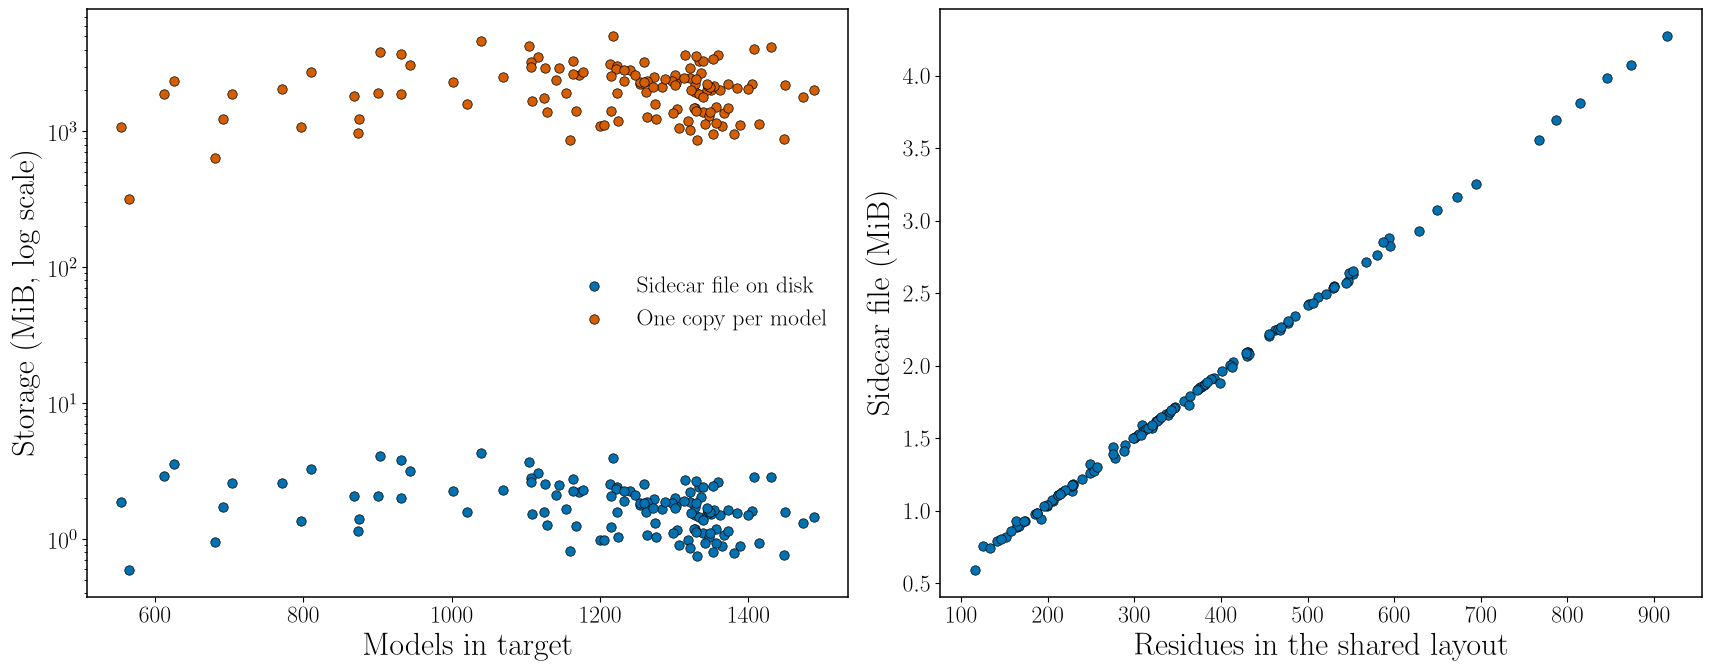

In [17]:
fig,axes=plt.subplots(1,2,figsize=(17,6.6),constrained_layout=True)
ax=axes[0]
contributing=cost.dropna(subset=['residues'])
ax.scatter(contributing.models,contributing.on_disk_mib,s=46,color=COLORS['eligible'],edgecolor='black',lw=.5,
           label='Sidecar file on disk')
ax.scatter(contributing.models,contributing.naive_gib*1024,s=46,color=COLORS['rejected'],edgecolor='black',lw=.5,
           label='One copy per model')
ax.set_yscale('log'); ax.set_xlabel('Models in target'); ax.set_ylabel('Storage (MiB, log scale)')
ax.legend(frameon=False,loc='center right')
ax=axes[1]
ax.scatter(contributing.residues,contributing.on_disk_mib,s=46,color=COLORS['eligible'],edgecolor='black',lw=.5)
ax.set_xlabel('Residues in the shared layout'); ax.set_ylabel('Sidecar file (MiB)')
save(fig,'sidecar_storage')

Sidecar size is flat in the number of models and linear in residue count, exactly as sharing predicts. The practical consequence is that the ESM preparation cost scales with the 125 distinct layouts, not with the 150,938 training graphs; the embedding work is essentially per-target.

## Readout

In [18]:
lines=[
 f'{len(audit)} targets audited under one audit-code signature; {raw_total:,} raw models, '
 f'{eligible_total:,} eligible ({100*eligible_total/raw_total:.1f}%), {rejected_total:,} rejected.',
 f'The eligible pool clears the launcher minimum of {LAUNCHER_MINIMUM:,} by {eligible_total-LAUNCHER_MINIMUM:,} models '
 f'({100*(eligible_total-LAUNCHER_MINIMUM)/LAUNCHER_MINIMUM:.2f}%) and falls {BUILDER_DEFAULT-eligible_total:,} short of the '
 f'conservative builder default of {BUILDER_DEFAULT:,}. This cohort exists only because the threshold was lowered deliberately.',
 f'{int((audit.eligible>0).sum())} targets contribute models, losing '
 f'{100*(1-nonempty.eligible_fraction.median()):.1f}% of their models at the median; '
 f'{int((audit.eligible==0).sum())} targets are fully rejected.',
 f'{reason_table.iloc[0].share_of_rejections_pct:.1f}% of rejections are a missing {reason_table.index[0].split()[-1]} dataset '
 f'and {100*reason_table.iloc[1].models/rejected_total:.1f}% a missing {reason_table.index[1].split()[-1]} group; '
 f'{int(reason_table.models.iloc[2:].sum())} model(s) fail a value check. The limit is incomplete feature propagation in the '
 'source graphs, not defective models.',
 f'All {eligible_total:,} eligible models belong to the complex.* family; the {int(family_table.loc[family_table.index!="complex","models"].sum()):,} '
 f'synthetic random_*/sampled_* models in {len(synthetic)} targets are rejected outright, and those targets contribute nothing.',
 f'Both frozen-split membership gates pass: no eligible target outside the split, no split target without eligible models. '
 f'Per-split eligible counts are {split_table.eligible_models.to_dict()}.',
 f'ESM2 sidecars cover the audited cohort exactly: {int(sidecar.expected.sum()):,} expected, {int(sidecar.accepted.sum()):,} accepted, '
 f'0 alignment failures, every embedding {ESM_WIDTH} wide at layer {ESM_LAYER}.',
 f'All {int(verified.models.sum()):,} model datasets were verified as hard links to {int(verified.stored_embeddings.sum())} shared '
 f'layouts, reducing {naive_bytes.sum()/2**30:,.0f} GiB of per-model copies to {disk_bytes.sum()/2**30:.2f} GiB.',
 'This is a coverage and provenance analysis. It reports no training, validation or test metric, and supports no claim about '
 'whether ESM2 features or either pooling variant improve DockQ prediction.',
 f'The obvious repair is targeted, not global: regenerating the missing derived features for the {len(fully_rejected)} fully '
 f'rejected targets and the partially affected files would restore up to {rejected_total:,} models and lift the cohort clear of '
 f'the {BUILDER_DEFAULT:,} default. Until then, treat the thin margin above {LAUNCHER_MINIMUM:,} as a standing fragility of this experiment.']
readout='\n\n'.join(lines)
(EXPORT/'readout.md').write_text(readout+'\n')
display(Markdown(readout))

146 targets audited under one audit-code signature; 189,710 raw models, 150,938 eligible (79.6%), 38,772 rejected.

The eligible pool clears the launcher minimum of 150,000 by 938 models (0.63%) and falls 29,062 short of the conservative builder default of 180,000. This cohort exists only because the threshold was lowered deliberately.

125 targets contribute models, losing 4.7% of their models at the median; 21 targets are fully rejected.

96.8% of rejections are a missing interface_node_degree dataset and 3.2% a missing node_features group; 1 model(s) fail a value check. The limit is incomplete feature propagation in the source graphs, not defective models.

All 150,938 eligible models belong to the complex.* family; the 25,208 synthetic random_*/sampled_* models in 19 targets are rejected outright, and those targets contribute nothing.

Both frozen-split membership gates pass: no eligible target outside the split, no split target without eligible models. Per-split eligible counts are {'train': 109147, 'val': 11325, 'test': 30466}.

ESM2 sidecars cover the audited cohort exactly: 150,938 expected, 150,938 accepted, 0 alignment failures, every embedding 1280 wide at layer 33.

All 150,938 model datasets were verified as hard links to 125 shared layouts, reducing 261 GiB of per-model copies to 0.22 GiB.

This is a coverage and provenance analysis. It reports no training, validation or test metric, and supports no claim about whether ESM2 features or either pooling variant improve DockQ prediction.

The obvious repair is targeted, not global: regenerating the missing derived features for the 21 fully rejected targets and the partially affected files would restore up to 38,772 models and lift the cohort clear of the 180,000 default. Until then, treat the thin margin above 150,000 as a standing fragility of this experiment.

## Limitations

- The audit reports are the evidence here; the source graphs are on the cluster and were not reopened. Model-level claims rest on what `validate_graph` recorded, and the stale-signature check in `build` that would catch a changed source file cannot run locally.
- A shared `audit_code` shows one code version produced every report. It does not prove that version matches this working tree.
- Split-level agreement with the earlier full-data manifests uses sample counts, not model-name lists. Identical counts are strong evidence of the same cohort, not proof.
- The association between synthetic decoy families and fully rejected targets is descriptive. Confirming the cause needs the source files, not these reports.
- Nothing here evaluates model quality. Eligibility was decided on features alone, and labels were only range-checked, so the cohort is not selected on performance — but neither is it evidence of any.